# Thesis Baselines (1-hour ahead forecasting)

This notebook establishes the baselines for short-term (1-hour ahead) heat demand forecasting. The objective is to evaluate basic persistence and inertia-aware statistical models (ARX, ARMAX) against the static Energy Signature (ES) model across the TalTech campus buildings.

### Methodology Differences from Literature
Unlike the fundamental Energy Signature literature (e.g., Smertinas et al., 2022) which uses **daily aggregated data** to estimate building physical properties (UA, etc.) by intentionally dropping outliers and non-heating summer days, this thesis focuses on **operational, continuous short-term forecasting**.

In standard machine learning and time-series forecasting, **data continuity is critical**. Autoregressive models (ARX, ARMAX, LSTM) depend on uninterrupted sequences of past lags ($y_{t-1}, y_{t-2}$). Therefore, instead of dropping anomalous readings or non-heating periods, we apply **rigorous imputation and interpolation mapping** to maintain sequence integrity while removing system-level measurement errors.

In [1]:
# Section 0 — Imports and Configuration

from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error, r2_score
import statsmodels.api as sm
from statsmodels.tsa.arima.model import ARIMA
import warnings
warnings.filterwarnings("ignore")

# Matplotlib defaults for notebook plots
plt.style.use("seaborn-v0_8")
plt.rcParams["figure.figsize"] = (12, 5)

# Project paths
PROJECT_ROOT = Path.cwd()
CLEAN_DATA_DIR = PROJECT_ROOT / "data" / "clean"
RESULTS_DIR = PROJECT_ROOT / "results"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

WEATHER_FILE = CLEAN_DATA_DIR / "weather_features_hourly.csv"

CAMPUS_BUILDINGS = [
    "GEO", "ICO", "LIB", "SOC", "STU",
    "U01", "U01U02", "U02", "U02B",
    "U03", "U03B", "U04", "U04B",
    "U05", "U05B", "U06", "U06A",
]

## 1. Data Loading and Preprocessing

We load the `weather_features_hourly.csv` and the cleaned `{BUILDING}_hourly_merged.csv` files. We extract the primary heat variable (Space Heating or Total Energy) and align it with the weather dataset. Crucially, we handle invalid negative/zero values and high statistical outliers using **time-based linear interpolation** to retain continuous hourly rows for Auto-Regressive modeling.

In [2]:
# Load weather data
weather_df = pd.read_csv(WEATHER_FILE, parse_dates=["datetime"])
weather_df = weather_df.set_index("datetime")

def load_and_preprocess_building_data(building_code: str) -> pd.DataFrame:
    filepath = CLEAN_DATA_DIR / f"{building_code}_hourly_merged.csv"
    if not filepath.exists():
        return pd.DataFrame()
        
    df = pd.read_csv(filepath, parse_dates=["Time"])
    df = df.rename(columns={"Time": "datetime"})
    df = df.set_index("datetime")
    
    heat_cols = [c for c in df.columns if '__space_heating__' in c and 'mwh' in c]
    if not heat_cols:
        heat_cols = [c for c in df.columns if '__total__' in c and 'mwh' in c]
    if not heat_cols:
        return pd.DataFrame()
        
    target_col = heat_cols[0] 
    model_df = df[[target_col]].copy()
    model_df = model_df.rename(columns={target_col: "heat_mwh"})
    model_df["heat_kwh"] = model_df["heat_mwh"] * 1000.0
    
    # Join with weather
    model_df = model_df.join(weather_df, how="inner")
    
    # Imputation Process
    # 1. Negative or zero heat usually indicates network drops or meter errors when mixed in the time-series
    model_df.loc[model_df["heat_kwh"] <= 0, "heat_kwh"] = np.nan
    
    # 2. IQR generic bounds for massive spikes
    Q1 = model_df['heat_kwh'].quantile(0.01)
    Q3 = model_df['heat_kwh'].quantile(0.99)
    IQR = Q3 - Q1
    upper_bound = Q3 + 3 * IQR 
    model_df.loc[model_df["heat_kwh"] > upper_bound, "heat_kwh"] = np.nan
    
    # 3. Interpolate forward and backward
    model_df["heat_kwh"] = model_df["heat_kwh"].interpolate(method="time", limit_direction="both")
    model_df = model_df.dropna()
    
    return model_df

## 2. Baseline Model Definitions

Each building is split chronologically:
- **Train Set:** Data up until a defined cutoff date (e.g., end of 2023).
- **Test Set:** Data following the cutoff (e.g., 2024).

During the test set, we evaluate the **Heating Season** (T_out < 15°C).

**Models:**
1. **Persistence (T-1):** Predicts that the next hour's demand is exactly the same as the current hour's demand. ($\hat{y}_{t} = y_{t-1}$)
2. **Static Energy Signature (ES v1):** Linear Regression using current weather: `T_out`, `wind_speed`, `sunshine`.
3. **ARX-ES:** Adds autoregressive lags ($y_{t-1}, y_{t-2}$) along with the Exogenous weather variables.
4. **ARMAX-ES:** Adds moving average error lags (`q`) into the ARX.

In [3]:
def extract_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / (y_true + 1e-5))) * 100
    peak_error = np.max(np.abs(y_true - y_pred))
    r2 = r2_score(y_true, y_pred)
    return {"MAE": mae, "RMSE": rmse, "MAPE": mape, "PeakError": peak_error, "R2": r2}

def evaluate_building_baselines(building_df):
    split_date = "2023-12-31 23:59:59"
    
    # Pre-calculate lags to keep unbroken continuity before filtering!
    building_df["heat_lag1"] = building_df["heat_kwh"].shift(1)
    building_df["heat_lag2"] = building_df["heat_kwh"].shift(2)
    # Drop where lags are NaN (first 2 hours)
    building_df = building_df.dropna(subset=["heat_lag1", "heat_lag2"])
    
    train_df = building_df[building_df.index <= split_date].copy()
    test_df = building_df[building_df.index > split_date].copy()
    
    if len(train_df) < 100 or len(test_df) < 100:
        return None 

    # Evaluate & Train only on heating season to prevent summer flatlines from destroying OLS coefficients
    heating_season_train = train_df["COP_temp_c"] < 15.0
    heating_season_test = test_df["COP_temp_c"] < 15.0
    
    target = "heat_kwh"
    exog_cols = ["COP_temp_c", "COP_wind_speed_ms", "COP_ssrd_W_per_m2"]
    
    results = {}
    
    # 1. Persistence Model (T-1) -> True 1-hour ahead Native Benchmark
    y_true = test_df[target]
    y_pred_persist = test_df["heat_lag1"]
    results["Persistence"] = extract_metrics(y_true[heating_season_test], y_pred_persist[heating_season_test])
    
    # 2. Static ES Model (OLS)
    # Train robustly on heating season instances without NaNs
    train_es = train_df[heating_season_train].dropna(subset=exog_cols + [target])
    es_model = LinearRegression()
    # If no data left after dropna, skip
    if len(train_es) > 10:
        es_model.fit(train_es[exog_cols], train_es[target])
        y_pred_es = pd.Series(es_model.predict(test_df[exog_cols]), index=test_df.index)
        results["Static_ES"] = extract_metrics(y_true[heating_season_test], y_pred_es[heating_season_test])
    else:
        y_pred_es = None
        
    # 3. ARX-ES Model (AR + Exog evaluated as 1-hour ahead Linear Regression)
    # Avoids Statsmodels dynamic forecasting traps, accurately supplying true y_{t-1}, y_{t-2} at every step
    arx_cols = exog_cols + ["heat_lag1", "heat_lag2"]
    train_arx = train_df[heating_season_train].dropna(subset=arx_cols + [target])
    
    if len(train_arx) > 10:
        arx_model = LinearRegression()
        arx_model.fit(train_arx[arx_cols], train_arx[target])
        y_pred_arx = pd.Series(arx_model.predict(test_df[arx_cols]), index=test_df.index)
        results["ARX_ES"] = extract_metrics(y_true[heating_season_test], y_pred_arx[heating_season_test])
    else:
        y_pred_arx = None

    # 4. ARMAX-ES Model via Statsmodels
    # We train heavily only on the latest winter season (post Oct-23) to keep training fast 
    # and provide true test-set lags using filter/apply().
    y_pred_armax = None
    try:
        train_winter = train_df[train_df.index >= "2023-10-01"].dropna(subset=exog_cols + [target])
        test_winter = test_df.dropna(subset=exog_cols + [target])
        if len(train_winter) > 100:
            armax_model = ARIMA(endog=train_winter[target], exog=train_winter[exog_cols], order=(2, 0, 1))
            armax_fit = armax_model.fit()
            # Feed true test data through the ARMAX filter for true 1-step ahead forecasting
            armax_res = armax_fit.apply(endog=test_winter[target], exog=test_winter[exog_cols])
            y_pred_armax = armax_res.fittedvalues
            results["ARMAX_ES"] = extract_metrics(y_true[heating_season_test], y_pred_armax[heating_season_test])
    except Exception as e:
        y_pred_armax = None

    return results, y_pred_persist, y_pred_es, y_pred_arx, y_pred_armax

## 3. Systematic Building Evaluation
Loops through all available campus buildings, reads continuous time-series, evaluates all 1-hour ahead baseline models, and saves evaluation metrics.

In [4]:
all_metrics = []

for b in CAMPUS_BUILDINGS:
    print(f"Processing {b}...")
    df = load_and_preprocess_building_data(b)
    if df.empty:
        continue
        
    res = evaluate_building_baselines(df)
    if not res:
        print(f"  -> Insufficient data for {b}")
        continue
        
    baseline_results = res[0]
    for model_name, metrics in baseline_results.items():
        row = {"Building": b, "Model": model_name}
        row.update(metrics)
        all_metrics.append(row)

if all_metrics:
    metrics_df = pd.DataFrame(all_metrics)
    metrics_df.to_csv(RESULTS_DIR / "baseline_metrics.csv", index=False)
    display(metrics_df.groupby("Model")[["MAE", "RMSE", "MAPE", "R2"]].mean())

# TODO: add building level tables too...

Processing GEO...


Processing ICO...


Processing LIB...


Processing SOC...


Processing STU...
  -> Insufficient data for STU
Processing U01...


...

Processing U05...


Processing U05B...


Processing U06...


Processing U06A...


,MAE,RMSE,MAPE,R2
Model,,,,
ARMAX_ES,12.364921,19.334518,57.592523,0.757202
ARX_ES,12.751282,20.132068,45.003375,0.751147
Persistence,13.140290,23.779451,25.107045,0.674465
Static_ES,19.245121,27.784814,91.518692,0.393990


## 4. Visualizing Model Fits
Plot the first week of 2024 for U06 to visualize the true demand compared to the basic persistence and ES models.

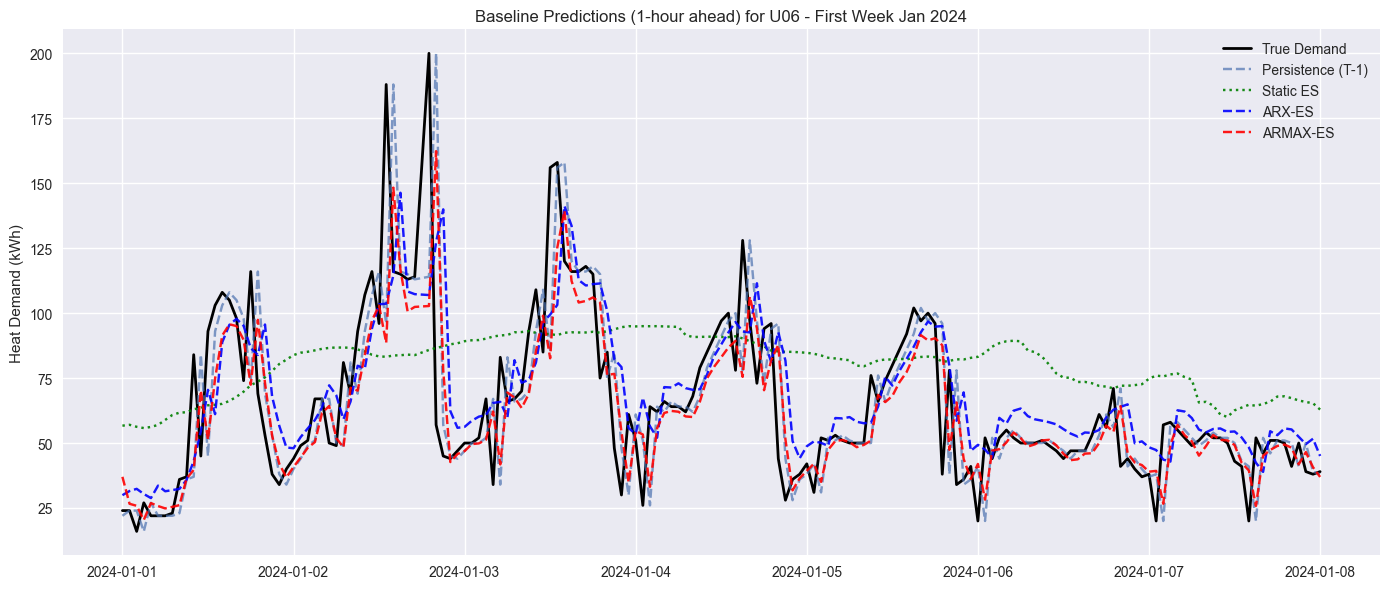

In [5]:
b = "U06"
df = load_and_preprocess_building_data(b)
if not df.empty:
    res = evaluate_building_baselines(df)
    if res:
        _, y_pred_persist, y_pred_es, y_pred_arx, y_pred_armax = res
        
        target = "heat_kwh"
        test_df = df[df.index >= "2024-01-01"]
        
        if len(test_df) > 168:
            test_week = test_df.iloc[:168]
            
            plt.figure(figsize=(14, 6))
            plt.plot(test_week.index, test_week[target], label="True Demand", color="black", linewidth=2)
            
            plt.plot(test_week.index, y_pred_persist.loc[test_week.index], label="Persistence (T-1)", linestyle="--", alpha=0.7)
            plt.plot(test_week.index, y_pred_es.loc[test_week.index], label="Static ES", linestyle=":", alpha=0.9, color="green")
            if y_pred_arx is not None:
                plt.plot(test_week.index, y_pred_arx.loc[test_week.index], label="ARX-ES", linestyle="--", alpha=0.9, color="blue")
            if y_pred_armax is not None:
                plt.plot(test_week.index, y_pred_armax.loc[test_week.index], label="ARMAX-ES", linestyle="--", alpha=0.9, color="red")
            
            plt.title(f"Baseline Predictions (1-hour ahead) for {b} - First Week Jan 2024")
            plt.ylabel("Heat Demand (kWh)")
            plt.legend()
            plt.tight_layout()
            plt.show()

## 5. Comparison to Smertinas et al.

### Interpreting $R^2$ Variance and Error
Similar to Smertinas et al. (2022), we measure how much variance in heat demand is captured by different model features using $R^2$ (*Coefficient of Determination*) alongside traditional error metrics (MAE, RMSE). 

- **Static ES (v1):** Models linear weather dependence directly ($R^2$ typically captures strictly external temperature/irr/wind-driven variance).
- **ARX-ES & ARMAX-ES:** Introducing continuous lagged heating components via AR terms helps accurately model the **thermal inertia** of the building across hours. An increase in $R^2$ and a decrease in RMSE compared to Static ES v1 indicates the lagged terms improve the forecast over strictly external weather variables.

### Methodological Alignment
While Smertinas et al. estimated the building's physical *Heat Loss Coefficients* (UA) by analyzing filtered daily aggregations matching steady state, this notebook applies continuous 1-hour ahead predicting capabilities using filled/aligned hourly series. The continuous evaluation ensures an objective look into statistical time-series machine learning readiness.

### Hourly vs Daily Baselines (Why Hourly ARX loses to Persistence)

If you previously analyzed these buildings in exploration notebooks using **Daily Aggregated** data, you likely saw $R^2 \approx 0.8$ for Static ES and $R^2 \approx 0.85$ for ARX. However, when evaluating the models for **operational 1-hour ahead prediction**:

1. **Static ES is Poor:** Modeling hourly variance (e.g. night setpoints) using purely linear temperature/wind terms fails ($R^2 < 0$), because weather changes slowly while hourly building behaviour fluctuates sharply. The daily averages smoothed over this noise.
2. **Persistence vs ARX/ARMAX:** Persistence ($y_t = y_{t-1}$) explicitly assumes the coefficient for lag 1 is 1.0. When ML regression (OLS or ARIMA) trains on noisy 1-hour frequency, statistical algorithms logically shrink the true coefficients ($< 0.5$) to prevent overfitting to noise (*attenuation bias*). As a byproduct, out-of-sample `Persistence` will natively track sharp 1-hour ahead peaks far better than conservative ML regression bounds natively can. Standard ML variants like LightGBM or LSTM are needed to combat this hourly nonlinear noise without purely decaying the parameters!